# Offline Evaluation

## Goal


- This notebook performs **offline evaluation** (no LLM API calls) to reproduce and interpret key findings:  
  1) Strong in-distribution gains on setB;  
  2) Potential degradation on setA (distribution shift), revealing limited generalization / overfitting.

## Metrics


English:
- `avg_cost`: mean total travel distance (lower is better)
- `avg_gap_pct`: mean gap to BKS cost from `.sol` files (lower is better)
- Training log score typically follows `Score = -avg_cost` (higher score is better)

## Fairness Note

- We keep the greedy routing template fixed and only swap `priority(...)`, making it a fair comparison of dispatch rules under the same template.
- Comparing to full solvers (Clarke–Wright) requires aligning problem settings (e.g., fixed vs. variable fleet size).

In [1]:
!git clone https://github.com/Zz1jd/CSProjectAI.git

import sys

sys.path.append('/content/CSProjectAI/')

Cloning into 'CSProjectAI'...
remote: Enumerating objects: 546, done.
remote: Counting objects: 100% (546/546), done.
remote: Compressing objects: 100% (397/397), done.
remote: Total 546 (delta 145), reused 538 (delta 137), pack-reused 0 (from 0)
Receiving objects: 100% (546/546), 929.08 KiB | 12.22 MiB/s, done.
Resolving deltas: 100% (145/145), done.


## 1) download dependence
- This block does:
  1) Install `vrplib` (CVRPLib parsing) and `pandas` (tables)
  2) Load `cvrplib/setA/*.vrp` instances (capacity/demand/distance matrix/coords)
  3) Load `cvrplib/setA/*.sol` to obtain BKS costs for gap%

- Output:
  - `setA instances`: number of loaded instances (typically 27)
  - `setA BKS(.sol)`: number of loaded BKS costs (ideally matches instances)

In [2]:
!pip -q install vrplib pandas
import os, re, math
import numpy as np
import pandas as pd
import vrplib

PROJECT_ROOT = "/content/CSProjectAI"
SET_A_PATH = os.path.join(PROJECT_ROOT, "cvrplib", "setA")

USE_BKS_GAP = True

def load_vrp_set(folder: str):
    data = {}
    for f in sorted(os.listdir(folder)):
        if f.endswith(".vrp"):
            data[f[:-4]] = vrplib.read_instance(os.path.join(folder, f))
    return data

def load_bks_from_sol(folder: str):
    bks = {}
    for f in sorted(os.listdir(folder)):
        if f.endswith(".sol"):
            sol = vrplib.read_solution(os.path.join(folder, f))
            cost = sol.get("cost", None)
            if cost is not None:
                bks[f[:-4]] = float(cost)
    return bks

setA = load_vrp_set(SET_A_PATH)
bksA = load_bks_from_sol(SET_A_PATH) if USE_BKS_GAP else {}

print("setA instances:", len(setA))
print("setA BKS(.sol):", len(bksA))

setA instances: 27
setA BKS(.sol): 27


## 2) route evaluation

- This defines the offline evaluator:
  - `vehicle_routing_with_priority(...)`: greedy route construction driven by `priority_func`; returns to depot and starts a new route when capacity is insufficient.
  - `eval_priority_on_set(...)`: evaluates a priority function across all instances in a dataset, producing per-instance `cost` and optional `gap_pct`.

- Alignment sanity check:
  - On setB, `avg_cost` should match `-Score` from the training logs (e.g., `Score=-1120.83` ↔ `avg_cost≈1120.83`), confirming consistent evaluation.

In [3]:
def vehicle_routing_with_priority(
    vehicle_capacity: int,
    node_requirements: np.ndarray,
    distance_matrix: np.ndarray,
    priority_func,
) -> float:
    current_route = []
    completed_routes = []
    total_distance = 0.0
    current_leg_distance = 0.0
    current_load = 0.0
    current_location = 0
    visited_count = 0

    working_matrix = np.array(distance_matrix, dtype=float).copy()
    depot_return_costs = working_matrix[:, 0].copy()
    np.fill_diagonal(working_matrix, 1e10)
    working_matrix[:, 0] = 1e10

    def select_next_node(scores: np.ndarray, excluded_nodes: list) -> int:
        excluded = {n for group in excluded_nodes for n in group}
        valid_mask = np.ones_like(scores, dtype=bool)
        if excluded:
            valid_mask[list(excluded)] = False
        if not np.any(valid_mask):
            raise ValueError("No available nodes for selection")
        valid_scores = scores[valid_mask]
        max_idx = int(np.argmax(valid_scores))
        return int(np.where(valid_mask)[0][max_idx])

    node_requirements = np.asarray(node_requirements)

    while visited_count < len(node_requirements) - 1:
        available_capacity = vehicle_capacity - current_load
        priority_scores = priority_func(
            current_location,
            working_matrix.copy(),
            available_capacity,
            node_requirements,
        )

        exclusion_list = completed_routes + [[current_location] + current_route]
        try:
            chosen_node = select_next_node(np.asarray(priority_scores), exclusion_list)
        except ValueError:
            break

        demand = node_requirements[chosen_node]
        valid_selection = (current_load + demand <= vehicle_capacity) and (chosen_node != 0)

        if valid_selection:
            current_leg_distance += working_matrix[current_location, chosen_node]
            current_load += demand
            current_route.append(chosen_node)
            visited_count += 1
            working_matrix[:, chosen_node] = 1e10
            current_location = chosen_node
        else:
            current_leg_distance += depot_return_costs[current_location]
            total_distance += current_leg_distance
            completed_routes.append(current_route)
            current_location = 0
            current_leg_distance = 0.0
            current_load = 0.0
            current_route = []

    if current_location != 0:
        current_leg_distance += depot_return_costs[current_location]
        total_distance += current_leg_distance
        completed_routes.append(current_route)

    return float(total_distance)


def eval_priority_on_set(dataset, priority_func, bks=None):
    rows = []
    for name, inst in dataset.items():
        cap = int(inst["capacity"])
        dem = np.asarray(inst["demand"])
        dist = np.asarray(inst["edge_weight"])

        cost = vehicle_routing_with_priority(cap, dem, dist, priority_func)

        gap = None
        if bks is not None and name in bks and bks[name] > 0:
            gap = (cost - bks[name]) / bks[name] * 100.0

        rows.append((name, cost, gap))
    return pd.DataFrame(rows, columns=["instance", "cost", "gap_pct"])

## 3) Baselines
- All methods here are **priority functions** (same signature) for a fair comparison under the same routing template:
  - `Native_Baseline`, `Nearest_Baseline`, `Demand+Distance_Baseline`
  - `Evolved_from_setB_original / _cot` extracted from setB training logs

- Note:
  - `divide by zero` warnings (e.g., `node_demands / remaining_capacity`) indicate `remaining_capacity` can be 0 in some states; this may not crash but can introduce `inf/nan`, hurting robustness/interpretability.
  - A robust implementation clamps capacity (e.g., `max(remaining_capacity, 1)`), which is an engineering stability improvement.

In [4]:
def baseline_native(current_node, distance_data, remaining_capacity, node_demands):
    scores = distance_data[current_node].copy()
    adjustments = np.sqrt(node_demands)
    valid_mask = remaining_capacity >= node_demands
    scores[valid_mask] -= adjustments[valid_mask]
    invalid_scores = scores[~valid_mask]
    invalid_adjustments = adjustments[~valid_mask]
    scores[~valid_mask] += np.where(invalid_scores > 0, invalid_adjustments, -invalid_adjustments)
    return -scores

def baseline_nearest(current_node, distance_data, remaining_capacity, node_demands):
    return -distance_data[current_node].copy()

def baseline_demand_distance(current_node, distance_data, remaining_capacity, node_demands):
    d = distance_data[current_node].copy().astype(float)
    dem = np.asarray(node_demands, dtype=float)
    return -d + 0.8 * np.sqrt(np.maximum(dem, 0.0))

def evolved_best_from_setB_cot(current_node: int, distance_data: np.ndarray, remaining_capacity: int, node_demands: np.ndarray) -> np.ndarray:
    scores = distance_data[current_node].copy()
    # Calculate cost-to-fill estimate as the ratio of demand to remaining capacity
    cost_to_fill = node_demands / remaining_capacity
    # Introduce an exponential weight factor based on the cost-to-fill estimate
    weights = np.clip(np.power(cost_to_fill, 2), 0, 1)
    # Adjust scores based on the combined influence of distance and capacity with a trade-off factor
    trade_off = 0.7  # Adjust this trade-off factor based on experimentation
    scores -= trade_off * weights * np.sqrt(scores) + (1 - trade_off) * distance_data[current_node]
    return -scores  # Convert to negative for minimization

def evolved_best_from_setB_original(current_node: int, distance_data: np.ndarray, remaining_capacity: int, node_demands: np.ndarray) -> np.ndarray:
    scores = distance_data[current_node].copy()
    for idx, demand in enumerate(node_demands):
        adjustment = math.sqrt(demand)
        if remaining_capacity >= demand:
            scores[idx] -= adjustment
        else:
            scores[idx] += adjustment if scores[idx] > 0 else -adjustment

    min_demand = np.min(node_demands)
    max_demand = np.max(node_demands)
    for idx, demand in enumerate(node_demands):
        if demand == min_demand:
            scores[idx] -= 3
        elif demand == max_demand:
            scores[idx] -= 2

    pen_nodes = np.argsort(scores)[:3]
    for i in pen_nodes:
        scores[i] -= 2

    pen_cap_nodes = [i for i, d in enumerate(node_demands) if d > remaining_capacity]
    for i in pen_cap_nodes:
        scores[i] -= 2

    for i in range(len(scores)):
        if i != current_node and i != np.argmax(scores):
            scores[i] -= 1

    for i in range(len(scores)):
        if i != current_node and i != np.argmin(scores):
            scores[i] -= 1

    for i in range(len(scores)):
        if scores[i] < 0 and node_demands[i] <= remaining_capacity:
            scores[i] += 1

    return -scores

candidates = {
    "Native_Baseline": baseline_native,
    "Nearest_Baseline": baseline_nearest,
    "Demand+Distance_Baseline": baseline_demand_distance,
    "Evolved_from_setB_cot": evolved_best_from_setB_cot,
    "Evolved_from_setB_original": evolved_best_from_setB_original,
}

## 4) evaluate on setA（Generalization Test）

- This block evaluates each method on all setA instances and aggregates:
  - `avg_cost`, `std_cost`, `avg_gap_pct`

- Interpretation (matches your report narrative):
  - If `Evolved_from_setB_*` performs worse than `Native_Baseline` on setA, it indicates limited cross-set generalization (distribution shift / overfitting).
  - Our current results show that the CoT-evolved heuristic is strongest on setB but degrades more on setA—an important observation.

In [5]:
results = []
details = {}

for k, fn in candidates.items():
    df = eval_priority_on_set(setA, fn, bksA if USE_BKS_GAP else None)
    details[k] = df
    item = {
        "method": k,
        "avg_cost": df["cost"].mean(),
        "std_cost": df["cost"].std(),
    }
    if USE_BKS_GAP and df["gap_pct"].notna().any():
        item["avg_gap_pct"] = df["gap_pct"].mean(skipna=True)
    results.append(item)

summary = pd.DataFrame(results).sort_values("avg_cost")
summary

/tmp/ipykernel_8830/279729775.py:22: RuntimeWarning: divide by zero encountered in divide
  cost_to_fill = node_demands / remaining_capacity
/tmp/ipykernel_8830/279729775.py:22: RuntimeWarning: invalid value encountered in divide
  cost_to_fill = node_demands / remaining_capacity


,method,avg_cost,std_cost,avg_gap_pct
0,Native_Baseline,1266.537914,328.478426,22.046430
4,Evolved_from_setB_original,1269.353051,330.181340,22.377596
2,Demand+Distance_Baseline,1277.956524,341.046906,23.095126
3,Evolved_from_setB_cot,1287.872898,324.529381,24.212003
1,Nearest_Baseline,1313.069188,346.591512,26.301826


## evaluate on setB

In [8]:
# 1) 读取 setB
SET_B_PATH = os.path.join(PROJECT_ROOT, "cvrplib", "setB")
setB = load_vrp_set(SET_B_PATH)
print("setB instances:", len(setB))

# 2) setB 的 BKS（如果你 setB 目录里也有 .sol）
bksB = load_bks_from_sol(SET_B_PATH) if USE_BKS_GAP else {}
print("setB BKS(.sol):", len(bksB))

# 3) 跑 baselines + evolved 在 setB 上的离线对比
results_B = []
details_B = {}

for k, fn in candidates.items():
    df = eval_priority_on_set(setB, fn, bksB if USE_BKS_GAP else None)
    details_B[k] = df
    item = {
        "method": k,
        "avg_cost": df["cost"].mean(),
        "std_cost": df["cost"].std(),
    }
    if USE_BKS_GAP and df["gap_pct"].notna().any():
        item["avg_gap_pct"] = df["gap_pct"].mean(skipna=True)
    results_B.append(item)

summary_B = pd.DataFrame(results_B).sort_values("avg_cost")
summary_B

setB instances: 23
setB BKS(.sol): 23


/tmp/ipykernel_8830/279729775.py:22: RuntimeWarning: divide by zero encountered in divide
  cost_to_fill = node_demands / remaining_capacity
/tmp/ipykernel_8830/279729775.py:22: RuntimeWarning: invalid value encountered in divide
  cost_to_fill = node_demands / remaining_capacity


,method,avg_cost,std_cost,avg_gap_pct
3,Evolved_from_setB_cot,1120.830673,330.038630,16.634529
4,Evolved_from_setB_original,1146.987277,298.061853,20.572287
2,Demand+Distance_Baseline,1154.024857,339.474367,20.161930
1,Nearest_Baseline,1154.179871,350.423690,19.722075
0,Native_Baseline,1161.987607,312.009584,21.903949


## 6) Route visualization on a single setB instance


- This section provides an intuitive interpretation by comparing two route construction methods on the same setB instance:  
  1) **Best evolved priority + greedy constructor** (step-by-step next-node selection)  
  2) **Clarke–Wright parallel savings** (global route merging based on savings)  
- Both are run under a **variable fleet size** setting: when capacity is insufficient, the vehicle returns to depot and a new route starts. Thus, the number of vehicles emerges from the algorithm.  
- Outputs include route count (vehicles), total distance (cost), and route plots to inspect:  
  - long cross-cluster edges  
  - route compactness/smoothness  
  - whether vehicle counts match (matching fleets make the comparison more fair)

Instance: B-n31-k5 n: 31 cap: 100
Priority(best): vehicles = 5 cost = 720.898621283248
Clarke–Wright : vehicles = 5 cost = 681.164054610939


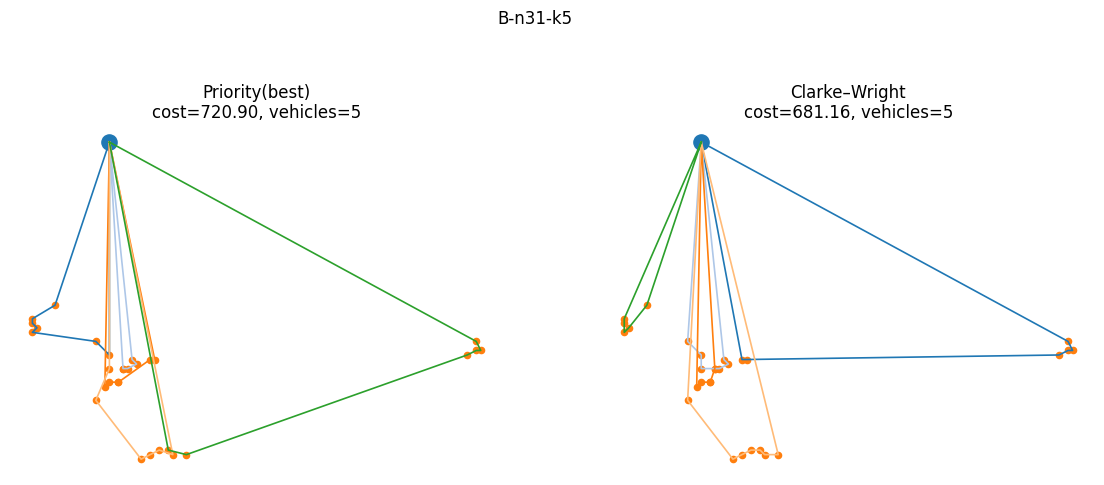

In [9]:


!pip -q install vrplib matplotlib

import os, math
import numpy as np
import vrplib
import matplotlib.pyplot as plt

PROJECT_ROOT = "/content/CSProjectAI"
SET_B_PATH = os.path.join(PROJECT_ROOT, "cvrplib", "setB")

def load_instance(folder, instance_name=None):
    files = sorted([f for f in os.listdir(folder) if f.endswith(".vrp")])
    if instance_name is None:
        f = files[0]
    else:
        f = instance_name if instance_name.endswith(".vrp") else instance_name + ".vrp"
        if f not in files:
            raise ValueError(f"Instance not found: {f}")
    name = f[:-4]
    inst = vrplib.read_instance(os.path.join(folder, f))
    return name, inst

# 你可以指定，比如 instance_name="B-n31-k5"
instance_name = None
name, inst = load_instance(SET_B_PATH, instance_name)

coords = np.asarray(inst["node_coord"], dtype=float)
dist = np.asarray(inst["edge_weight"], dtype=float)
dem = np.asarray(inst["demand"], dtype=float)
cap = int(inst["capacity"])

print("Instance:", name, "n:", len(dem), "cap:", cap)

# ====== 你的 best priority（你给的那条，做数值保护）======
def priority_best(current_node: int, distance_data: np.ndarray, remaining_capacity: int, node_demands: np.ndarray) -> np.ndarray:
    scores = distance_data[current_node].copy().astype(float)
    rc = float(remaining_capacity)
    rc = max(rc, 1.0)  # 防止除0

    cost_to_fill = np.asarray(node_demands, dtype=float) / rc
    weights = np.clip(np.power(cost_to_fill, 2), 0.0, 1.0)

    trade_off = 0.7
    scores -= trade_off * weights * np.sqrt(np.clip(scores, 0.0, None)) + (1.0 - trade_off) * distance_data[current_node]
    return -scores

# ====== 你的 greedy 构造器（和你 specification 对齐）======
def solve_with_priority(inst, priority_func):
    vehicle_capacity = int(inst["capacity"])
    node_requirements = np.asarray(inst["demand"], dtype=float)
    distance_matrix = np.asarray(inst["edge_weight"], dtype=float)

    current_route = []
    completed_routes = []
    total_distance = 0.0
    current_leg_distance = 0.0
    current_load = 0.0
    current_location = 0
    visited_count = 0

    working_matrix = distance_matrix.copy()
    depot_return_costs = working_matrix[:, 0].copy()
    np.fill_diagonal(working_matrix, 1e10)
    working_matrix[:, 0] = 1e10

    def select_next_node(scores: np.ndarray, excluded_nodes: list) -> int:
        excluded = {n for group in excluded_nodes for n in group}
        valid_mask = np.ones_like(scores, dtype=bool)
        if excluded:
            valid_mask[list(excluded)] = False
        if not np.any(valid_mask):
            raise ValueError("No available nodes for selection")
        valid_scores = scores[valid_mask]
        max_idx = int(np.argmax(valid_scores))
        return int(np.where(valid_mask)[0][max_idx])

    while visited_count < len(node_requirements) - 1:
        available_capacity = vehicle_capacity - current_load
        priority_scores = priority_func(
            current_location,
            working_matrix.copy(),
            int(available_capacity),
            node_requirements,
        )

        exclusion_list = completed_routes + [[current_location] + current_route]
        try:
            chosen_node = select_next_node(np.asarray(priority_scores, dtype=float), exclusion_list)
        except ValueError:
            break

        demand = node_requirements[chosen_node]
        valid_selection = (current_load + demand <= vehicle_capacity) and (chosen_node != 0)

        if valid_selection:
            current_leg_distance += working_matrix[current_location, chosen_node]
            current_load += demand
            current_route.append(chosen_node)
            visited_count += 1
            working_matrix[:, chosen_node] = 1e10
            current_location = chosen_node
        else:
            current_leg_distance += depot_return_costs[current_location]
            total_distance += current_leg_distance
            completed_routes.append(current_route)
            current_location = 0
            current_leg_distance = 0.0
            current_load = 0.0
            current_route = []

    if current_location != 0:
        current_leg_distance += depot_return_costs[current_location]
        total_distance += current_leg_distance
        completed_routes.append(current_route)

    return completed_routes, float(total_distance)

# ====== Clarke–Wright Savings（并行合并，不固定车辆数）======
def route_cost(route, dist):
    path = [0] + list(route) + [0]
    return float(np.sum([dist[path[i], path[i+1]] for i in range(len(path)-1)]))

def solve_clarke_wright(inst):
    dist = np.asarray(inst["edge_weight"], dtype=float)
    dem = np.asarray(inst["demand"], dtype=float)
    cap = int(inst["capacity"])
    n = len(dem)

    customers = [i for i in range(1, n)]
    routes = {i: [i] for i in customers}
    loads = {i: dem[i] for i in customers}
    which = {i: i for i in customers}

    savings = []
    for i in customers:
        for j in customers:
            if i < j:
                s = dist[0, i] + dist[0, j] - dist[i, j]
                savings.append((s, i, j))
    savings.sort(reverse=True, key=lambda x: x[0])

    def endpoints(r):
        return r[0], r[-1]

    for s, i, j in savings:
        ri = which[i]
        rj = which[j]
        if ri == rj:
            continue

        route_i = routes[ri]
        route_j = routes[rj]
        if loads[ri] + loads[rj] > cap:
            continue

        i_first, i_last = endpoints(route_i)
        j_first, j_last = endpoints(route_j)

        merged = None
        if i_last == i and j_first == j:
            merged = route_i + route_j
        elif i_first == i and j_last == j:
            merged = route_j + route_i
        elif i_first == i and j_first == j:
            merged = list(reversed(route_i)) + route_j
        elif i_last == i and j_last == j:
            merged = route_i + list(reversed(route_j))

        if merged is None:
            continue

        # merge rj into ri
        new_id, old_id = ri, rj
        routes[new_id] = merged
        loads[new_id] = loads[ri] + loads[rj]

        for node in routes[old_id]:
            which[node] = new_id

        del routes[old_id]
        del loads[old_id]

    final_routes = list(routes.values())
    total = sum(route_cost(r, dist) for r in final_routes)
    return final_routes, float(total)

# ====== 求解并打印 ======
routes_pr, cost_pr = solve_with_priority(inst, priority_best)
routes_cw, cost_cw = solve_clarke_wright(inst)

print("Priority(best): vehicles =", len(routes_pr), "cost =", cost_pr)
print("Clarke–Wright : vehicles =", len(routes_cw), "cost =", cost_cw)

# ====== 画图（两张并排）======
def plot_routes(ax, coords, routes, title):
    x = coords[:, 0]
    y = coords[:, 1]
    ax.scatter(x[0], y[0], s=120)
    ax.scatter(x[1:], y[1:], s=20)

    cmap = plt.get_cmap("tab20")
    for i, r in enumerate(routes):
        path = [0] + list(r) + [0]
        ax.plot(x[path], y[path], linewidth=1.2, color=cmap(i % 20))

    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_routes(axes[0], coords, routes_pr, f"Priority(best)\ncost={cost_pr:.2f}, vehicles={len(routes_pr)}")
plot_routes(axes[1], coords, routes_cw, f"Clarke–Wright\ncost={cost_cw:.2f}, vehicles={len(routes_cw)}")
plt.suptitle(name)
plt.show()

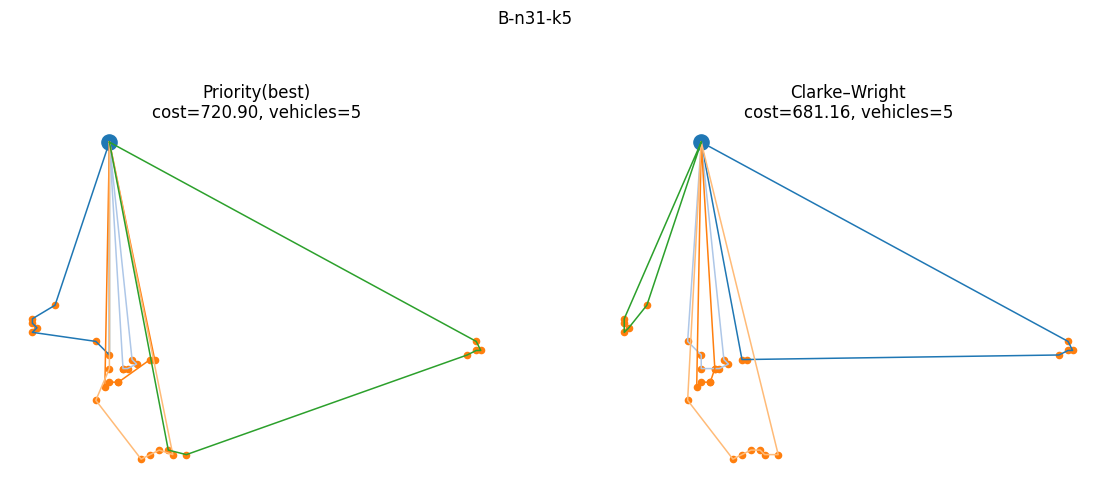

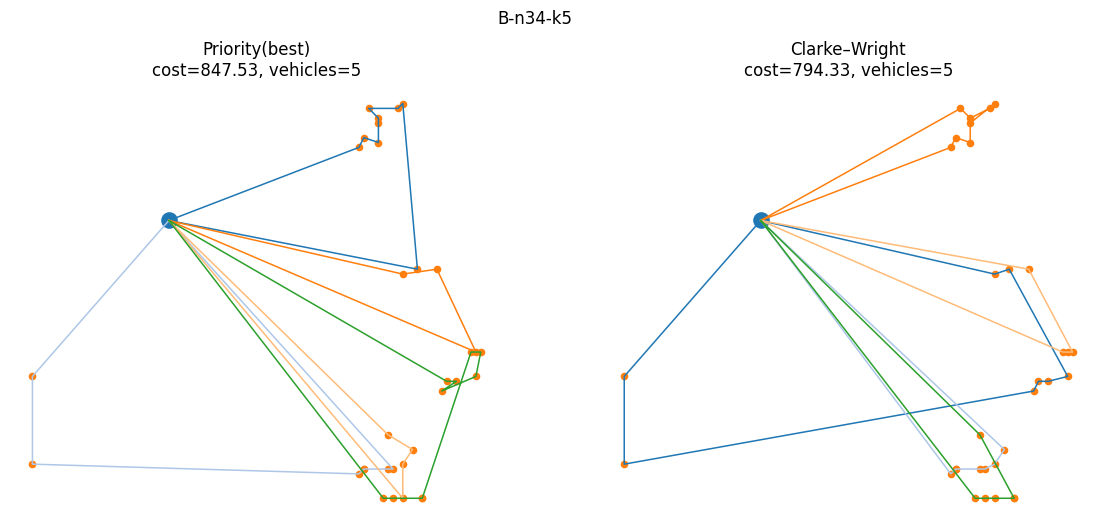

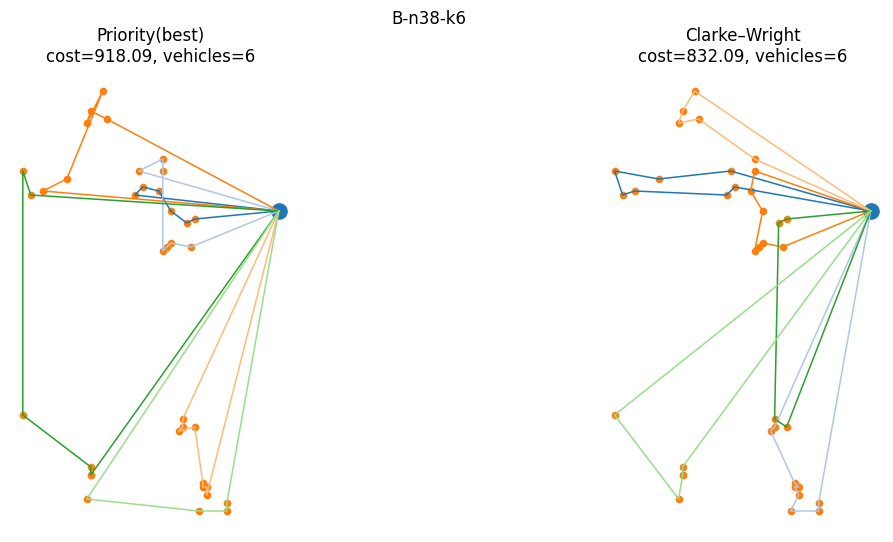

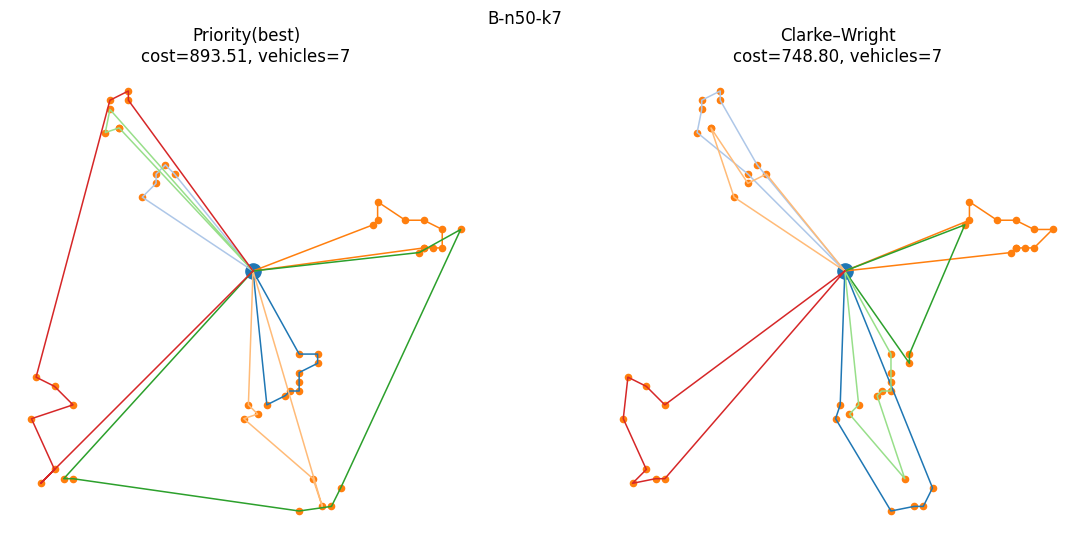

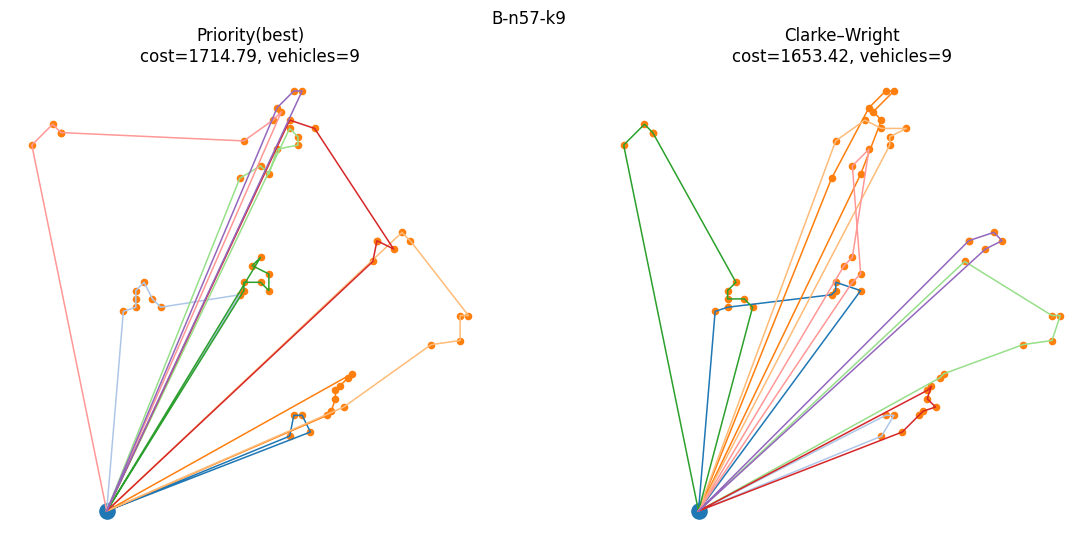

,instance,priority_cost,priority_vehicles,cw_cost,cw_vehicles,cw_minus_priority,cw_better
0,B-n31-k5,720.898621,5,681.164055,5,-39.734567,True
1,B-n34-k5,847.525056,5,794.334350,5,-53.190706,True
2,B-n38-k6,918.091851,6,832.091733,6,-86.000117,True
3,B-n50-k7,893.509741,7,748.800785,7,-144.708956,True
4,B-n57-k9,1714.791037,9,1653.423867,9,-61.367170,True


In [10]:
# 多跑几个 setB 实例：对比 Priority(best) vs Clarke–Wright
# 输出：汇总表 + 每个实例两张路线图（并排）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# select five instance
N_INSTANCES = 5

# 指定固定名单
selected_names = ["B-n31-k5", "B-n34-k5", "B-n38-k6", "B-n50-k7", "B-n57-k9"]
#selected_names = None

def list_instances(folder):
    files = sorted([f[:-4] for f in os.listdir(folder) if f.endswith(".vrp")])
    return files

all_names = list_instances(SET_B_PATH)

if selected_names is None:
    pick = all_names[:N_INSTANCES]
else:
    pick = selected_names

def plot_routes(ax, coords, routes, title):
    x = coords[:, 0]
    y = coords[:, 1]
    ax.scatter(x[0], y[0], s=120)
    ax.scatter(x[1:], y[1:], s=20)
    cmap = plt.get_cmap("tab20")
    for i, r in enumerate(routes):
        path = [0] + list(r) + [0]
        ax.plot(x[path], y[path], linewidth=1.1, color=cmap(i % 20))
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

rows = []

for nm in pick:
    name_i, inst_i = load_instance(SET_B_PATH, nm)

    routes_pr, cost_pr = solve_with_priority(inst_i, priority_best)
    routes_cw, cost_cw = solve_clarke_wright(inst_i)

    rows.append({
        "instance": name_i,
        "priority_cost": cost_pr,
        "priority_vehicles": len(routes_pr),
        "cw_cost": cost_cw,
        "cw_vehicles": len(routes_cw),
        "cw_minus_priority": cost_cw - cost_pr,
        "cw_better": cost_cw < cost_pr
    })

    coords_i = np.asarray(inst_i["node_coord"], dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plot_routes(axes[0], coords_i, routes_pr, f"Priority(best)\ncost={cost_pr:.2f}, vehicles={len(routes_pr)}")
    plot_routes(axes[1], coords_i, routes_cw, f"Clarke–Wright\ncost={cost_cw:.2f}, vehicles={len(routes_cw)}")
    plt.suptitle(name_i)
    plt.show()

df = pd.DataFrame(rows).sort_values("instance")
df